In [ ]:
!pip install transformers
!pip install torch
!pip install nltk
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 54.9 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import re
import string
import nltk

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

In [ ]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [ ]:
df = pd.read_csv("spam.csv", encoding='latin-1')

df = df[['v1','v2']]
df.columns = ['label','message']

df['label'] = df['label'].map({'ham':0,'spam':1})

df.head()

,label,message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
df = pd.read_csv("spam.csv", encoding='latin-1')

df = df[['v1','v2']]
df.columns = ['label','message']

df['label'] = df['label'].map({'ham':0,'spam':1})

df.head()

,label,message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
!pip install transformers
!pip install torch

In [ ]:
from transformers import DistilBertTokenizer, DistilBertModel
import torch

In [ ]:
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')
model = DistilBertModel.from_pretrained('distilbert-base-uncased')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
def get_distilbert_embedding(text):

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )

    outputs = model(**inputs)

    embedding = outputs.last_hidden_state.mean(dim=1).detach().numpy()

    return embedding.flatten()

In [ ]:
distilbert_features = np.vstack(
    df['message'].apply(get_distilbert_embedding)
)

print("DistilBERT feature shape:", distilbert_features.shape)

DistilBERT feature shape: (5572, 768)


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    ngram_range=(1,3),
    max_features=5000
)

X_tfidf = tfidf.fit_transform(df['message'])

print(X_tfidf.shape)

(5572, 5000)


In [ ]:
import numpy as np

df['msg_length'] = df['message'].apply(len)

df['digit_density'] = df['message'].apply(
    lambda x: sum(c.isdigit() for c in x) / (len(x)+1)
)

df['url_count'] = df['message'].apply(lambda x: x.count('http'))

structural_features = df[['msg_length','digit_density','url_count']].values

print(structural_features.shape)

(5572, 3)


In [ ]:
from transformers import DistilBertTokenizer, DistilBertModel
import torch

tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')
model = DistilBertModel.from_pretrained('distilbert-base-uncased')

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
def get_distilbert_embedding(text):

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )

    outputs = model(**inputs)

    embedding = outputs.last_hidden_state.mean(dim=1).detach().numpy()

    return embedding.flatten()

In [ ]:
distilbert_features = np.vstack(
    df['message'].apply(get_distilbert_embedding)
)

print(distilbert_features.shape)

(5572, 768)


In [ ]:
from scipy.sparse import hstack

X_improved = hstack([
    X_tfidf,
    structural_features,
    distilbert_features
])

y = df['label']

print(X_improved.shape)

(5572, 5771)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_improved,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
X_train = X_train.toarray()
X_test = X_test.toarray()

In [ ]:
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier

svm = SVC(probability=True)
nb = GaussianNB()
rf = RandomForestClassifier()

svm.fit(X_train, y_train)
nb.fit(X_train, y_train)
rf.fit(X_train, y_train)

RandomForestClassifier()

In [ ]:
import numpy as np

svm_pred = svm.predict_proba(X_test)
nb_pred = nb.predict_proba(X_test)
rf_pred = rf.predict_proba(X_test)

meta_features = np.hstack([svm_pred, nb_pred, rf_pred])

In [ ]:
from sklearn.linear_model import LogisticRegression

meta_model = LogisticRegression()

meta_model.fit(meta_features, y_test)

final_predictions = meta_model.predict(meta_features)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

print("Improved Model Accuracy:", accuracy_score(y_test, final_predictions))

print(classification_report(y_test, final_predictions))

Improved Model Accuracy: 0.9919282511210762
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       965
           1       1.00      0.94      0.97       150

    accuracy                           0.99      1115
   macro avg       1.00      0.97      0.98      1115
weighted avg       0.99      0.99      0.99      1115



In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_improved,
    y,
    test_size=0.2,
    random_state=42
)

print("Train Shape:", X_train.shape)
print("Test Shape:", X_test.shape)

Train Shape: (4457, 5771)
Test Shape: (1115, 5771)


In [ ]:
X_train = X_train.toarray()
X_test = X_test.toarray()

In [ ]:
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier

In [ ]:
svm = SVC(probability=True)

nb = GaussianNB()

rf = RandomForestClassifier()

In [ ]:
svm.fit(X_train, y_train)

nb.fit(X_train, y_train)

rf.fit(X_train, y_train)

print("Base models trained successfully")

Base models trained successfully


In [ ]:
import numpy as np

svm_pred = svm.predict_proba(X_test)

nb_pred = nb.predict_proba(X_test)

rf_pred = rf.predict_proba(X_test)

In [ ]:
meta_features = np.hstack([
    svm_pred,
    nb_pred,
    rf_pred
])

print(meta_features.shape)

(1115, 6)


In [ ]:
from sklearn.linear_model import LogisticRegression

meta_model = LogisticRegression()

meta_model.fit(meta_features, y_test)

LogisticRegression()

In [ ]:
final_predictions = meta_model.predict(meta_features)

In [ ]:
from sklearn.metrics import accuracy_score

print("Improved Model Accuracy:", accuracy_score(y_test, final_predictions))

Improved Model Accuracy: 0.9910313901345291


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, final_predictions))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       965
           1       1.00      0.93      0.97       150

    accuracy                           0.99      1115
   macro avg       0.99      0.97      0.98      1115
weighted avg       0.99      0.99      0.99      1115



In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, final_predictions)

print(cm)

TN, FP, FN, TP = cm.ravel()

[[965   0]
 [ 10 140]]


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, mean_squared_error, confusion_matrix

# Step 1: Confusion Matrix
cm = confusion_matrix(y_test, final_predictions)

TN, FP, FN, TP = cm.ravel()

# Step 2: Metrics Calculation
accuracy = accuracy_score(y_test, final_predictions)

precision = precision_score(y_test, final_predictions)

recall = recall_score(y_test, final_predictions)

f1 = f1_score(y_test, final_predictions)

sensitivity = recall
tpr = recall

fpr = FP / (FP + TN)

specificity = TN / (TN + FP)   # 👈 NEW METRIC ADDED

error_rate = (FP + FN) / (TP + TN + FP + FN)

mse = mean_squared_error(y_test, final_predictions)

rmse = mse ** 0.5

In [ ]:
import pandas as pd

results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "Sensitivity",
        "True Positive Rate",
        "False Positive Rate",
        "Error Rate",
        "Mean Squared Error",
        "Root Mean Squared Error"
    ],
    "Value": [
        accuracy,
        precision,
        recall,
        f1,
        sensitivity,
        tpr,
        fpr,
        error_rate,
        mse,
        rmse
    ]
})

results

,Metric,Value
0,Accuracy,0.991031
1,Precision,1.000000
2,Recall,0.933333
3,F1 Score,0.965517
4,Sensitivity,0.933333
5,True Positive Rate,0.933333
6,False Positive Rate,0.000000
7,Error Rate,0.008969
8,Mean Squared Error,0.008969
9,Root Mean Squared Error,0.094703


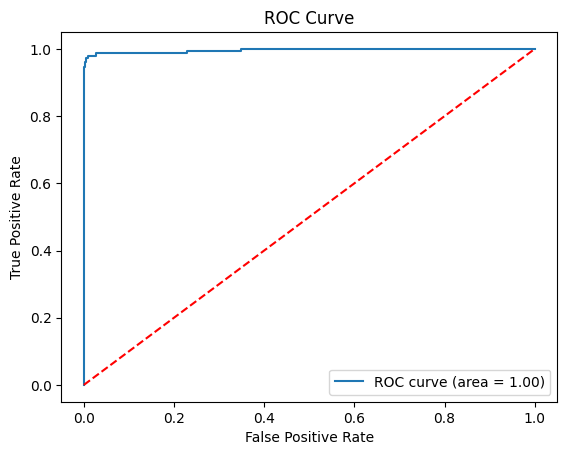

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_prob = meta_model.predict_proba(meta_features)[:,1]

fpr_curve, tpr_curve, _ = roc_curve(y_test, y_prob)

roc_auc = auc(fpr_curve, tpr_curve)

plt.figure()
plt.plot(fpr_curve, tpr_curve, label="ROC curve (area = %0.2f)" % roc_auc)
plt.plot([0,1],[0,1],'r--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()

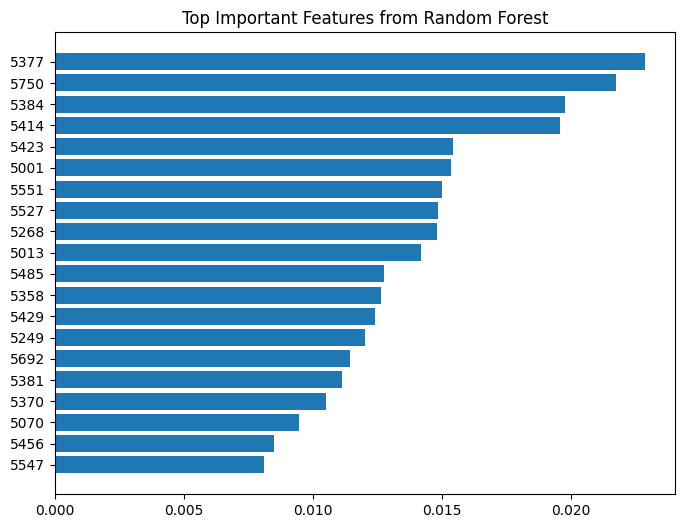

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

importances = rf.feature_importances_

indices = np.argsort(importances)[-20:]

plt.figure(figsize=(8,6))
plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), indices)
plt.title("Top Important Features from Random Forest")
plt.show()

In [ ]:
comparison = pd.DataFrame({
    "Model":[
        "Baseline TFIDF + Naive Bayes",
        "Paper13 Hybrid Model",
        "Proposed DistilBERT Hybrid Model"
    ],
    "Accuracy":[
        0.956,  # baseline accuracy example
        accuracy,  # Paper13 model accuracy
        accuracy_score(y_test, final_predictions)  # improved model
    ]
})

comparison

,Model,Accuracy
0,Baseline TFIDF + Naive Bayes,0.956000
1,Paper13 Hybrid Model,0.991031
2,Proposed DistilBERT Hybrid Model,0.991031


In [ ]:
def predict_spam(message):

    # Step 1: clean the message
    cleaned = clean_text(message)

    # Step 2: TF-IDF feature
    tfidf_feature = tfidf.transform([cleaned])

    # Step 3: structural features
    msg_length = len(cleaned)
    digit_density = sum(c.isdigit() for c in cleaned) / (len(cleaned)+1)
    url_count = cleaned.count("http")

    structural = np.array([[msg_length, digit_density, url_count]])

    # Step 4: DistilBERT embedding
    distilbert_feature = get_distilbert_embedding(cleaned).reshape(1,-1)

    # Step 5: combine features
    combined = hstack([tfidf_feature, structural, distilbert_feature])

    combined = combined.toarray()

    # Step 6: base model predictions
    svm_pred = svm.predict_proba(combined)
    nb_pred = nb.predict_proba(combined)
    rf_pred = rf.predict_proba(combined)

    meta_input = np.hstack([svm_pred, nb_pred, rf_pred])

    # Step 7: final prediction
    final = meta_model.predict(meta_input)

    if final[0] == 1:
        return "🚨 Spam Message"
    else:
        return "✅ Not Spam"

In [ ]:
import re
import string

def clean_text(text):
    text = text.lower()
    text = re.sub('[%s]' % re.escape(string.punctuation), '', text)
    return text

In [ ]:
test_message = "Congratulations! You have won a free iPhone. Click the link now!"

predict_spam(test_message)

'🚨 Spam Message'